In [24]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras import Model
from time import time
from collections import Counter

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

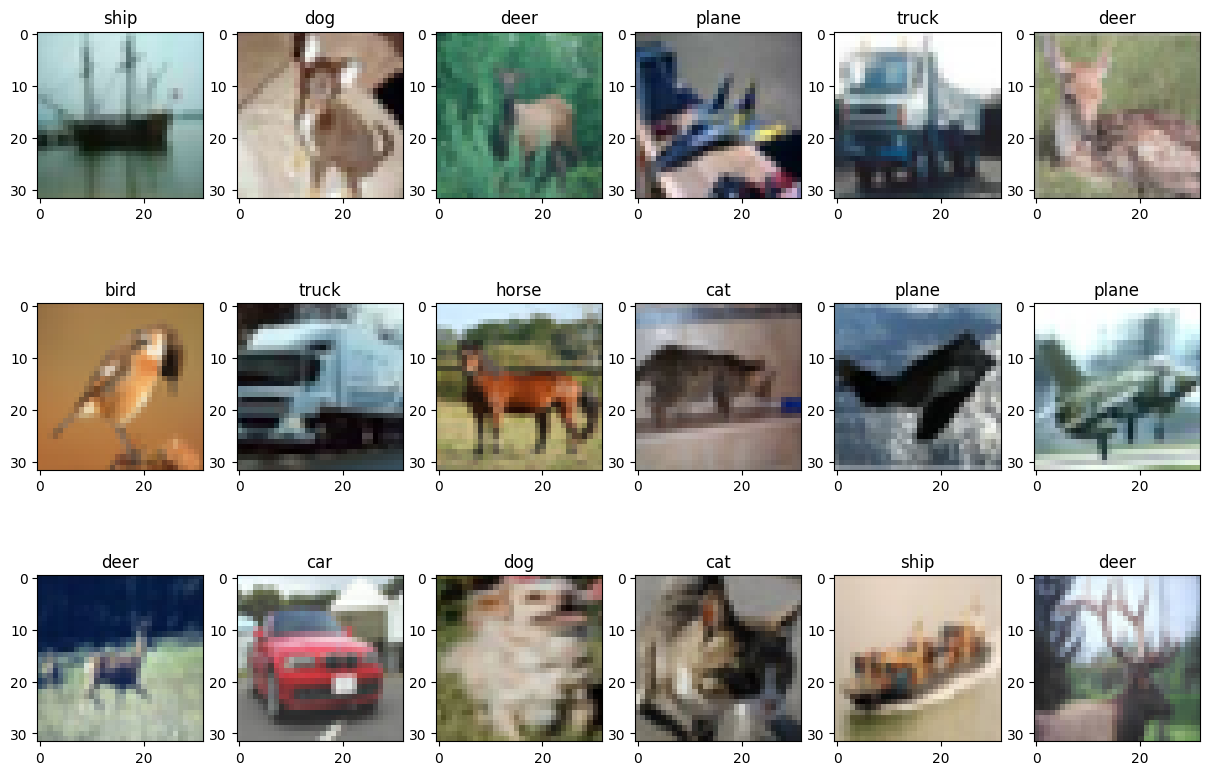

In [19]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Mapping from class ID to class name
classes = {
    0: "plane",
    1: "car",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}

# Dataset params
num_classes = len(classes)
size = x_train.shape[1]

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):
    plt.subplot(3, 6, ii + 1)
    train_items_count = x_train.shape[0]
    # Pick a random sample
    idx = np.random.randint(0, train_items_count)
    # Show the image and the label
    plt.imshow(x_train[idx, ...])
    plt.title(classes[y_train[idx][0]])

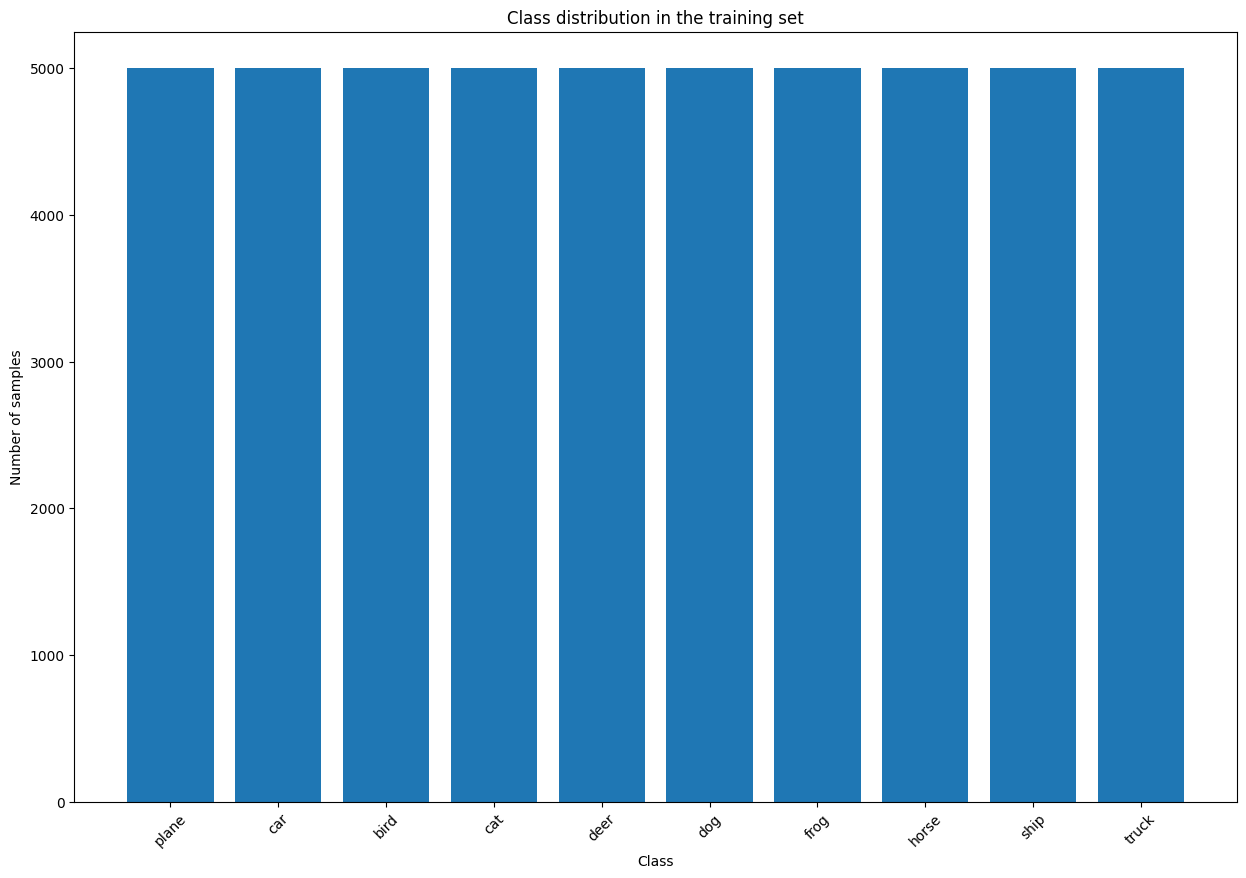

In [27]:
# compute histogram of classes in the training set
class_counts = Counter(y_train.flatten())
# plot the histogram
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(list(classes.keys()), list(classes.values()), rotation=45)
plt.title("Class distribution in the training set")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.show()

In [28]:
# Normalization
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


In [29]:
# Build the classifier
model = tf.keras.Sequential([
    Input(shape=(size, size, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Show the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
epochs = 25
batch_size = 128

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size,
                    validation_data=(x_test, y_test))

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.3875 - loss: 1.6704 - val_accuracy: 0.4835 - val_loss: 1.4019
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5328 - loss: 1.3020 - val_accuracy: 0.5224 - val_loss: 1.3332
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5963 - loss: 1.1417 - val_accuracy: 0.5865 - val_loss: 1.1758
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.6388 - loss: 1.0283 - val_accuracy: 0.6299 - val_loss: 1.0647
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.6676 - loss: 0.9476 - val_accuracy: 0.6528 - val_loss: 1.0051
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.6923 - loss: 0.8806 - val_accuracy: 0.6593 - val_loss: 0.9920
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7144 - loss: 0.8205 - val_accuracy: 0.6522 - val_loss: 1.0172
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7328 - loss: 0.7692 - val_accu

Train Acc      0.8769999742507935
Validation Acc 0.6970000267028809


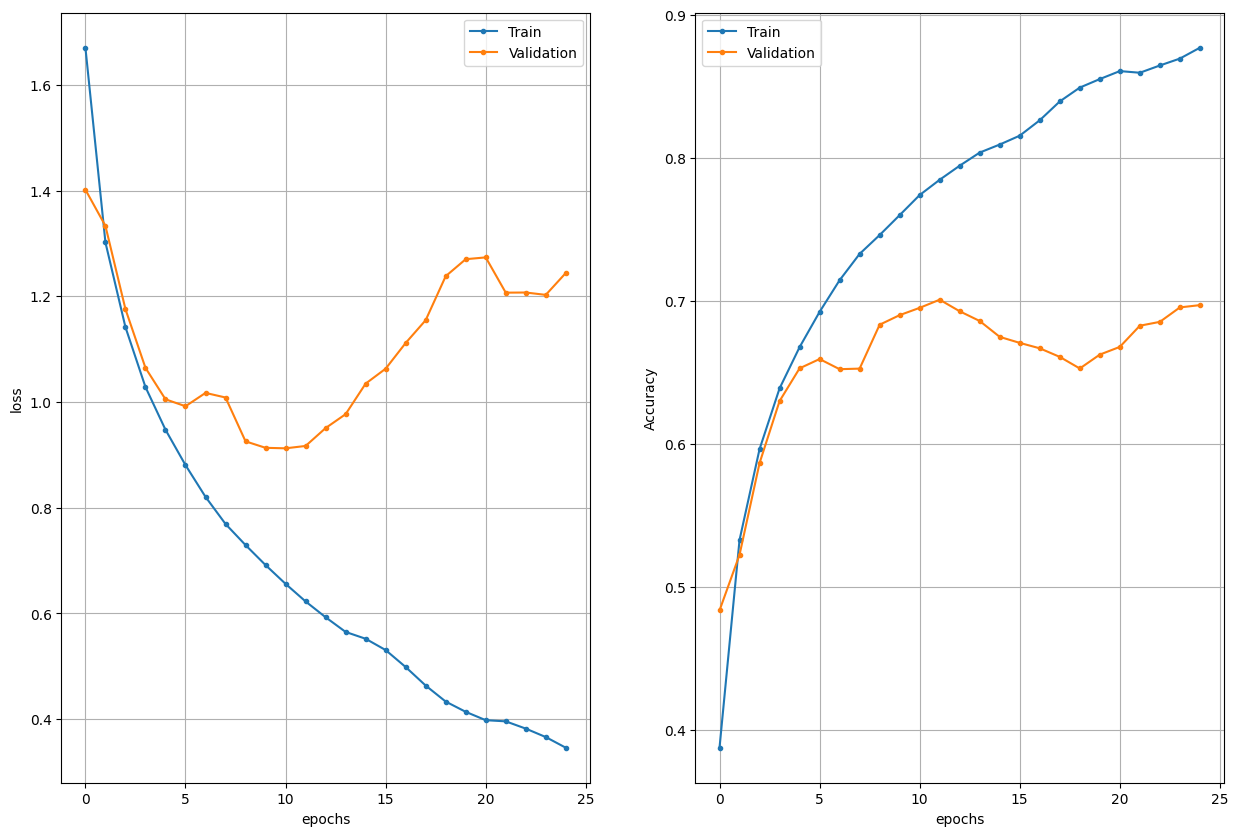

In [ ]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epoch_axis = range(len(h['loss']))

plt.subplot(121), plt.plot(epoch_axis, h['loss'], '.-', epoch_axis, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epoch_axis, h['accuracy'], '.-',
                           epoch_axis, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1]) 

In [33]:
# Compute the labels and the predictions as sparse values
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [34]:
# Compute and print the accuracy for each class
for class_id, class_name in classes.items():
    acc = np.mean(y_true[y_true == class_id] == y_pred[y_true == class_id])
    print(class_name, acc)

plane 0.716
car 0.808
bird 0.7
cat 0.43
deer 0.622
dog 0.571
frog 0.748
horse 0.788
ship 0.794
truck 0.793


In [35]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6970 - loss: 1.2442
Test loss   1.2441885471343994
Test metric 0.6970000267028809


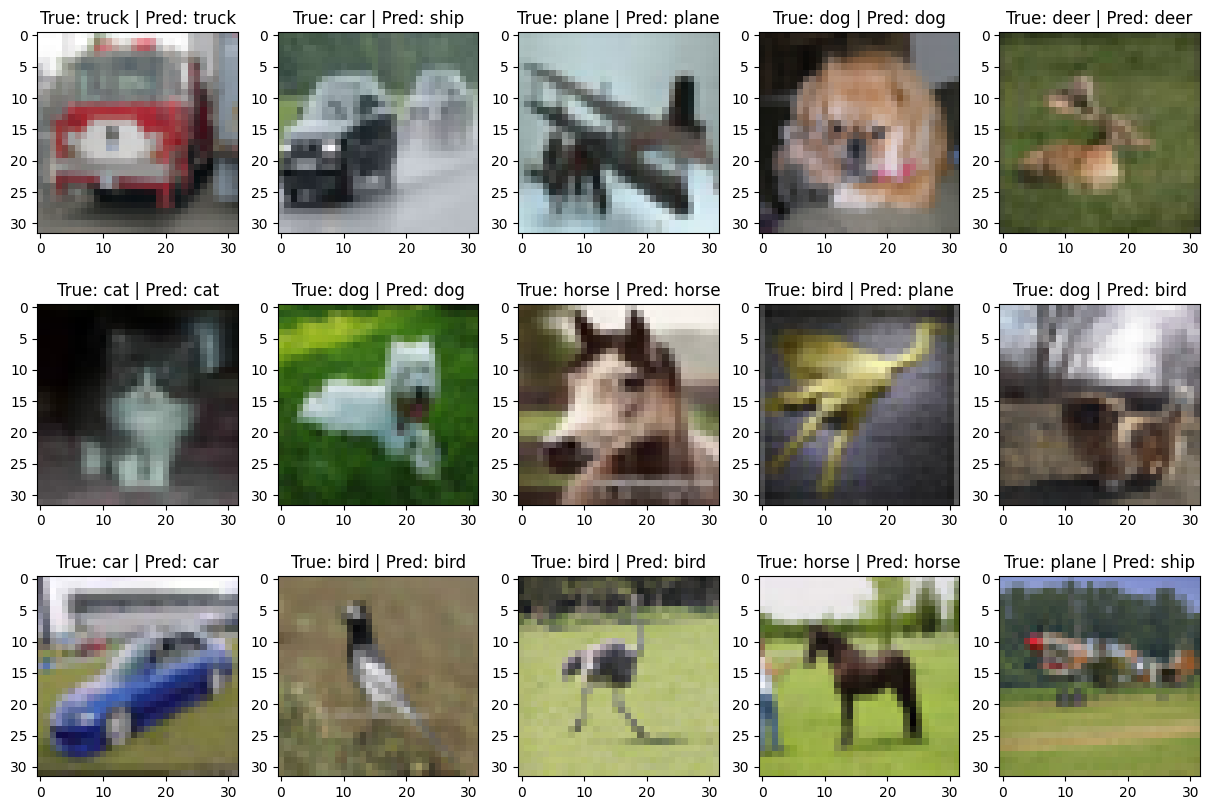

In [36]:
# Show random samples
for ii in range(15):
    train_items_count = x_test.shape[0]
    # Pick a random sample
    idx = np.random.randint(0, train_items_count)
    # Show the results
    plt.subplot(3,5,ii+1), plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_true[idx]]) + ' | Pred: ' + str(classes[y_pred[idx]]))

Final train acc: 0.877
Final val acc: 0.697
Test metric from evaluate: 0.697
Per-class accuracy sorted:
cat 0.43
dog 0.571
deer 0.622
bird 0.7
plane 0.716
frog 0.748
horse 0.788
truck 0.793
ship 0.794
car 0.808


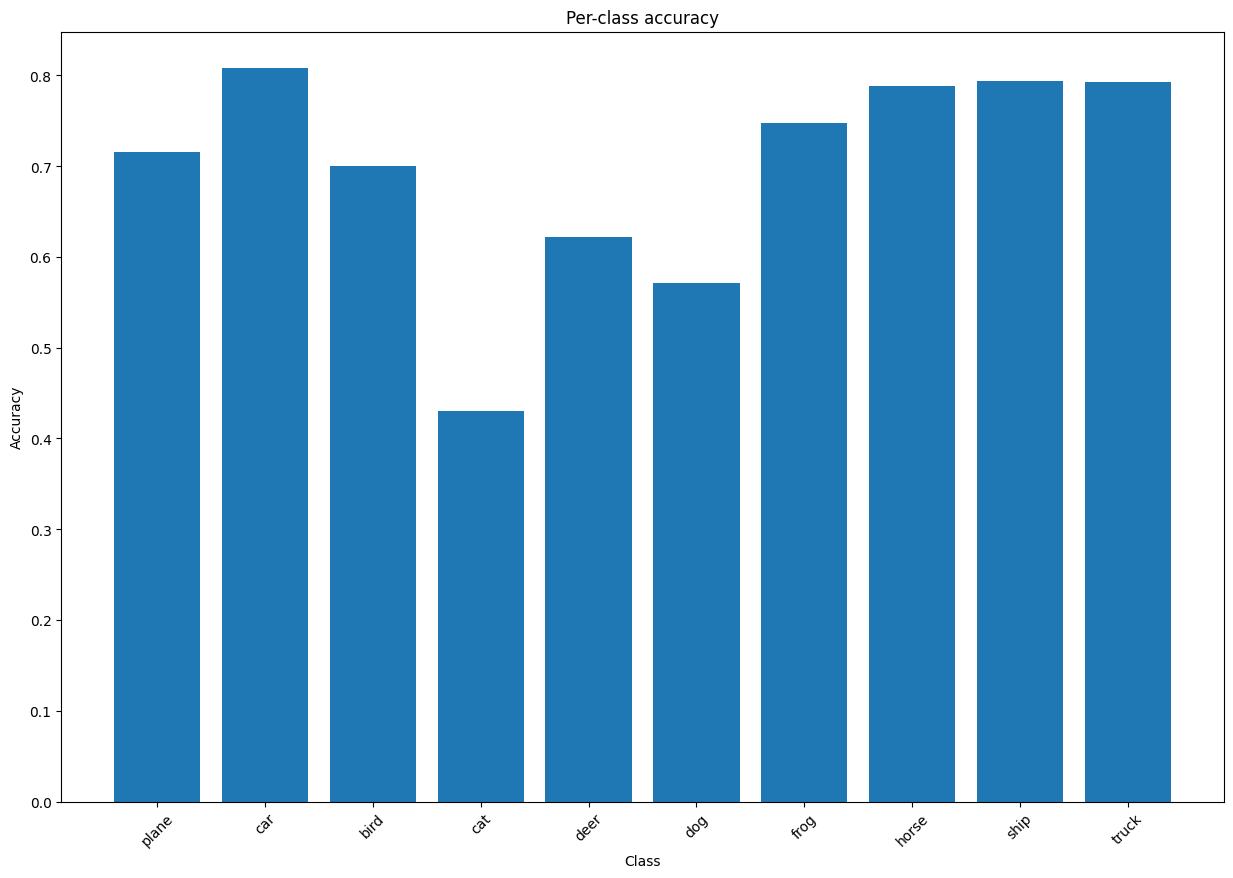

In [40]:
# Let's compute the per-class accuracy and print it sorted
print('Final train acc:', round(float(h['accuracy'][-1]), 4))
print('Final val acc:', round(float(h['val_accuracy'][-1]), 4))
print('Test metric from evaluate:', round(float(ev[1]), 4))

class_acc = {}
for class_id, class_name in classes.items():
    acc = np.mean(y_true[y_true == class_id] == y_pred[y_true == class_id])
    class_acc[class_name] = round(float(acc), 4)

print('Per-class accuracy sorted:')
for k, v in sorted(class_acc.items(), key=lambda kv: kv[1]):
    print(k, v)

plt.bar(class_acc.keys(), class_acc.values())
plt.xticks(rotation=45)
plt.title("Per-class accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.show()

> Здесь видно что точность распознование котов и собак значительно уступает. Так же по графикам видноo overfitting. Попробуем улучшить результат добавив Dropout.

In [ ]:
# Add Dropout to the model to reduce overfitting
from tensorflow.keras.layers import Dropout

train_epochs = 25
train_batch_size = 128

model = tf.keras.Sequential([
    Input(shape=(size, size, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train, epochs=train_epochs, batch_size=train_batch_size,
                    validation_data=(x_test, y_test))

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.3665 - loss: 1.7047 - val_accuracy: 0.4588 - val_loss: 1.4838
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.5079 - loss: 1.3692 - val_accuracy: 0.5454 - val_loss: 1.2891
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.5596 - loss: 1.2341 - val_accuracy: 0.5761 - val_loss: 1.1872
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.5939 - loss: 1.1445 - val_accuracy: 0.6021 - val_loss: 1.1287
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6201 - loss: 1.0779 - val_accuracy: 0.6387 - val_loss: 1.0292
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.6420 - loss: 1.0190 - val_accuracy: 0.6478 - val_loss: 0.9895
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6557 - loss: 0.9810 - val_accuracy: 0.6743 - val_loss: 0.9423
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6678 - loss: 0.9442 - val_accu

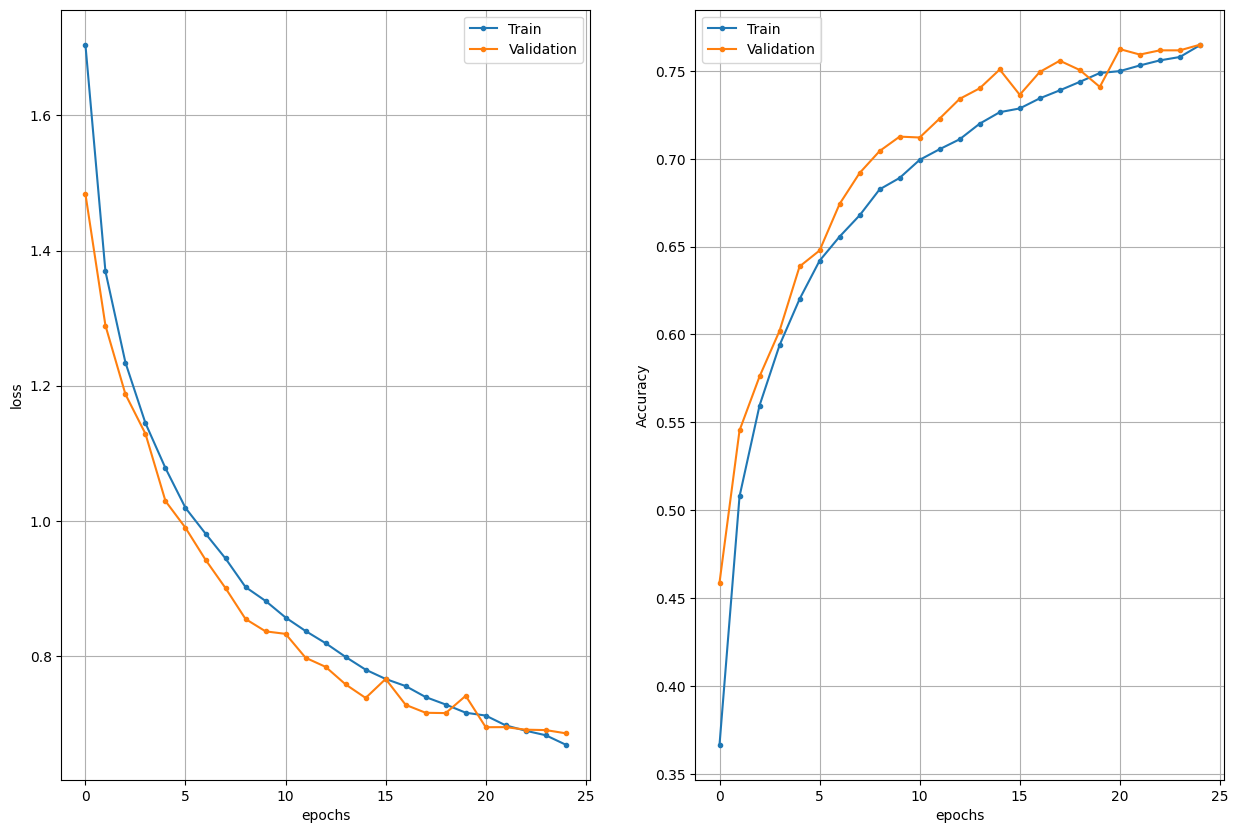

In [49]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epoch_axis = range(len(h['loss']))
plt.subplot(121), plt.plot(epoch_axis, h['loss'], '.-', epoch_axis, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epoch_axis, h['accuracy'], '.-',
                            epoch_axis, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [55]:
# Compute the labels and the predictions as sparse values
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Final train acc: 0.7646
Final val acc: 0.7649
Test metric from evaluate: 0.7649
Per-class accuracy sorted:
cat 0.519
bird 0.661
dog 0.726
deer 0.735
plane 0.763
horse 0.809
truck 0.812
frog 0.862
ship 0.879
car 0.883


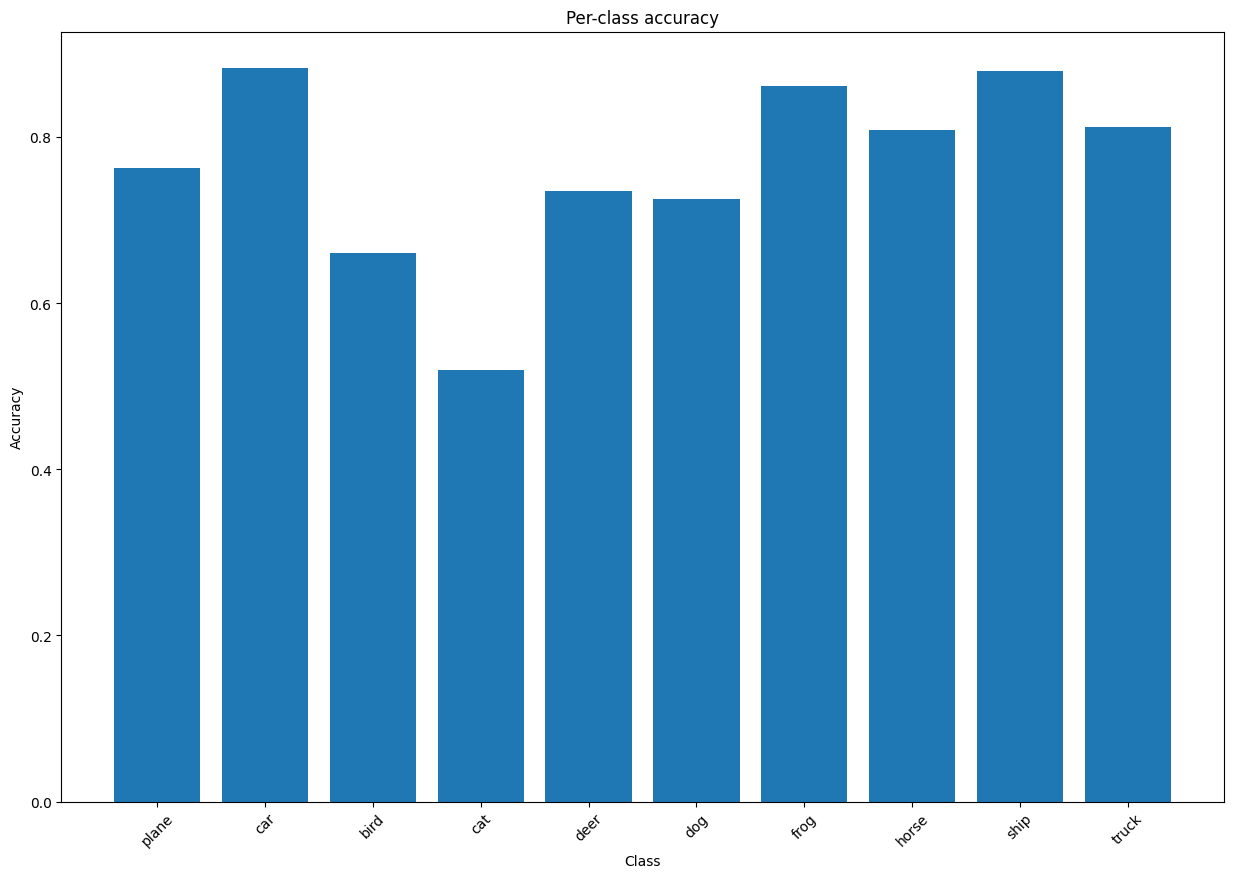

In [59]:
# Let's compute the per-class accuracy and print it sorted
# Evaluate the retrained model on test data to get the current test metric
ev = model.evaluate(x_test, y_test, verbose=0)

print('Final train acc:', round(float(h['accuracy'][-1]), 4))
print('Final val acc:', round(float(h['val_accuracy'][-1]), 4))
print('Test metric from evaluate:', round(float(ev[1]), 4))

class_acc = {}
for class_id, class_name in classes.items():
    acc = np.mean(y_true[y_true == class_id] == y_pred[y_true == class_id])
    class_acc[class_name] = round(float(acc), 4)

print('Per-class accuracy sorted:')
for k, v in sorted(class_acc.items(), key=lambda kv: kv[1]):
    print(k, v)

plt.bar(class_acc.keys(), class_acc.values())
plt.xticks(rotation=45)
plt.title("Per-class accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.show()

> После добавления Dropout слоев удалось значитьельно уменьшить Overfitting, так же удалось достичь большой точности распознования всех класов подтянуть выше распознование собак, однако коты все еще распознаются хуже. Train точность упала, но Validation и Test точность выросла, что говорит нам о том, что модель стала лучше обобщать, а не запоминать тренировочные данные.

>До добавления Dropout общая точность была:
Final train acc: 0.877
Final val acc: 0.697
Test metric from evaluate: 0.697

>После добавления Dropout общая точность стала:
> После добавления Dropout слоев удалось значитьельно уменьшить Overfitting, так же удалось достичь большой точности распознования всех класов подтянуть выше распознование собак, однако коты все еще распознаются хуже.

>До добавления Dropout общая точность была:
Final train acc: 0.7646
Final val acc: 0.7649
Test metric from evaluate: 0.7649